In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from factor_engine import FactorEngine

In [2]:
cwd = Path(os.getcwd())
data_path = cwd / "data" / "spx_1y_ohlcv.parquet"
long_table = pd.read_parquet(data_path)
fe = FactorEngine(long_table)

## Spot check a few factors

In [3]:
#
target_factor = fe.wq010()

In [6]:
"""
Cross-secitonal IC (daily): correlation between t factor value and t+1 return
Below is generated by Google AI mode
The "Rule of Thumb" Thresholds
------------------------------
IC Value        Interpretation
------------------------------
< 0.01          Noise. Virtually no predictive power.
0.02 - 0.03	    Solid. This is a very common range for many institutional factors (like classic Fama-French factors).
0.05+	        Excellent. This is considered a "Strong" alpha factor in liquid markets (A-shares or US Equities).
> 0.10	        Suspicious / Holy Grail. If you see this consistently, check for Look-ahead Bias (using future data to predict the past) or extreme concentration in small-cap/illiquid stocks.
------------------------------
"""
daily_ic = target_factor.corrwith(fe.ret.shift(-1), axis=1, method="spearman")
daily_ic_mean = daily_ic.mean()
print(daily_ic_mean)
if daily_ic_mean < 0.01:
    print("This might be just noise")
elif daily_ic_mean < 0.02:
    print("Slightly better than noise")
elif daily_ic_mean <= 0.03:
    print("Very common range for many institutional factors")
elif daily_ic_mean <= 0.05:
    print("Very good IC")
elif daily_ic_mean <= 0.1:
    print("Suspicously good")
else:
    print("Too suspicous. Are you sure?")

0.0021268517586049414
This might be just noise


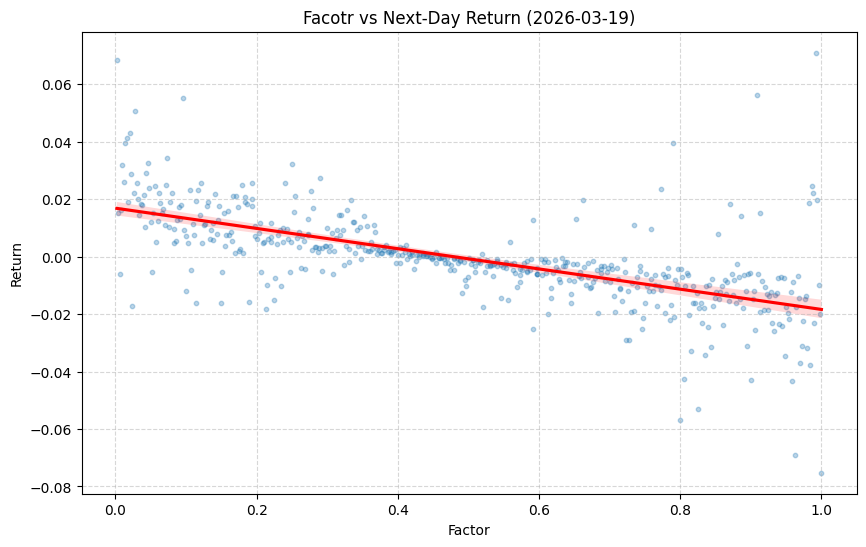

In [7]:
# Plot the latest comparison
latest_date = target_factor.index[-2]
x = target_factor.loc[latest_date]
y = fe.ret.loc[latest_date]

plot_data = pd.DataFrame({"Factor": x, "Return": y}).dropna()
plt.figure(figsize=(10, 6))

sns.regplot(
    # Data
    data=plot_data, 
    x="Factor",
    y="Return",
    # Styles
    scatter_kws={"alpha":0.3, "s":10},  # alpha for transparency, s for size
    line_kws={"color":"red"}            # regression line colour
)          

plt.title(f"Facotr vs Next-Day Return ({latest_date.date()})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()